In [1]:
!pip install pandas numpy matplotlib scipy scikit-learn statsmodels lifelines seaborn yfinance --quiet
print("Libraries installed!")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 8.9 MB/s eta 0:00:00
Libraries installed!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from lifelines import CoxPHFitter, KaplanMeierFitter
from scipy import stats
import statsmodels.api as sm
from datetime import datetime

warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#0A1628'
plt.rcParams['axes.facecolor']   = '#0A1628'
plt.rcParams['axes.edgecolor']   = '#1E3A5F'
plt.rcParams['text.color']       = 'white'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['grid.color']       = '#1E3A5F'
plt.rcParams['grid.alpha']       = 0.4
plt.rcParams['font.family']      = 'monospace'

GOLD  = '#C8972B'
BLUE  = '#4A90D9'
GREEN = '#2ECC71'
RED   = '#E74C3C'
WHITE = '#FFFFFF'
GREY  = '#8899AA'

# APRA/IFRS 9 parameters
LGD_UNSECURED   = 0.45   # 45% LGD for unsecured corporate (Basel III)
LGD_SECURED     = 0.25   # 25% LGD for secured
DISCOUNT_RATE   = 0.0435 # RBA cash rate for ECL discounting
N_LOANS         = 200    # Hypothetical loan book size

print("=" * 60)
print("  IFRS 9 EXPECTED CREDIT LOSS MODEL")
print("  APRA APS 220 Aligned | Australian Corporate Loan Book")
print("=" * 60)
print(f"  LGD (unsecured) : {LGD_UNSECURED*100:.0f}%")
print(f"  LGD (secured)   : {LGD_SECURED*100:.0f}%")
print(f"  Discount rate   : {DISCOUNT_RATE*100:.2f}% (RBA cash rate)")
print(f"  Loan book size  : {N_LOANS} exposures")
print("=" * 60)

  IFRS 9 EXPECTED CREDIT LOSS MODEL
  APRA APS 220 Aligned | Australian Corporate Loan Book
  LGD (unsecured) : 45%
  LGD (secured)   : 25%
  Discount rate   : 4.35% (RBA cash rate)
  Loan book size  : 200 exposures


In [3]:
print("\nSimulating ASX corporate loan book...")
np.random.seed(42)

# GICS sectors for Australian corporate loans
sectors = ['Financials', 'Materials', 'Healthcare', 'Consumer Disc',
           'Consumer Staples', 'Technology', 'Energy', 'Industrials', 'Real Estate']

sector_weights = [0.25, 0.20, 0.10, 0.10, 0.08, 0.07, 0.08, 0.07, 0.05]

loan_book = pd.DataFrame({
    'loan_id'      : range(N_LOANS),
    'sector'       : np.random.choice(sectors, N_LOANS, p=sector_weights),
    'exposure_AUD' : np.random.lognormal(mean=14.5, sigma=1.2, size=N_LOANS),
    'tenor_years'  : np.random.choice([1, 2, 3, 5, 7, 10], N_LOANS,
                                       p=[0.15, 0.20, 0.25, 0.20, 0.12, 0.08]),
    'secured'      : np.random.choice([0, 1], N_LOANS, p=[0.40, 0.60]),
})

# Financial features (Altman Z-score components + others)
loan_book['interest_coverage'] = np.random.lognormal(mean=1.5, sigma=0.8, size=N_LOANS)
loan_book['net_leverage']      = np.random.lognormal(mean=1.2, sigma=0.7, size=N_LOANS)
loan_book['current_ratio']     = np.random.lognormal(mean=0.4, sigma=0.4, size=N_LOANS)
loan_book['roa']               = np.random.normal(0.05, 0.06, size=N_LOANS)
loan_book['revenue_growth']    = np.random.normal(0.04, 0.12, size=N_LOANS)
loan_book['ebitda_margin']     = np.random.normal(0.18, 0.10, size=N_LOANS)

# Altman Z-score proxy (simplified for private firms)
loan_book['altman_z'] = (
    1.2 * loan_book['current_ratio'] +
    1.4 * loan_book['roa'] +
    3.3 * (loan_book['ebitda_margin'] * 0.3) +
    0.6 / (loan_book['net_leverage'] + 0.1) +
    1.0 * loan_book['revenue_growth']
)

# Generate default events
# Higher probability for: high leverage, low ICR, negative ROA, low Z-score
default_prob_true = 1 / (1 + np.exp(
    3.0
    - 0.8 * loan_book['interest_coverage']
    + 0.6 * loan_book['net_leverage']
    - 2.0 * loan_book['roa']
    - 0.4 * loan_book['altman_z']
    + 0.3 * (loan_book['sector'] == 'Energy').astype(int)
    - 0.2 * (loan_book['sector'] == 'Healthcare').astype(int)
))

loan_book['defaulted']        = np.random.binomial(1, default_prob_true)
loan_book['time_to_default']  = np.where(
    loan_book['defaulted'] == 1,
    np.random.uniform(0.1, loan_book['tenor_years'], N_LOANS),
    loan_book['tenor_years']
)
loan_book['lgd'] = np.where(loan_book['secured'] == 1, LGD_SECURED, LGD_UNSECURED)
loan_book['exposure_AUD'] = loan_book['exposure_AUD'].clip(500_000, 500_000_000)

print(f"Loan book generated: {N_LOANS} exposures")
print(f"Total exposure    : AUD {loan_book['exposure_AUD'].sum()/1e9:.2f}B")
print(f"Default rate      : {loan_book['defaulted'].mean()*100:.1f}%")
print(f"Avg tenor         : {loan_book['tenor_years'].mean():.1f} years")
print(f"Secured %         : {loan_book['secured'].mean()*100:.0f}%")
print(f"\nSector breakdown:")
print(loan_book.groupby('sector')['defaulted'].agg(['count','sum','mean']).round(3))


Simulating ASX corporate loan book...
Loan book generated: 200 exposures
Total exposure    : AUD 0.99B
Default rate      : 44.0%
Avg tenor         : 4.0 years
Secured %         : 59%

Sector breakdown:
                  count  sum   mean
sector                             
Consumer Disc        18    7  0.389
Consumer Staples     14    8  0.571
Energy               16    8  0.500
Financials           56   30  0.536
Healthcare           20    8  0.400
Industrials          18    9  0.500
Materials            40   13  0.325
Real Estate           8    2  0.250
Technology           10    3  0.300


In [4]:
print("\nFitting Probability of Default (PD) model...")

features = ['interest_coverage', 'net_leverage', 'current_ratio',
            'roa', 'revenue_growth', 'ebitda_margin', 'altman_z']

X = loan_book[features].values
y = loan_book['defaulted'].values

# Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Logistic Regression PD model
pd_model = LogisticRegression(random_state=42, max_iter=1000, C=1.0)
pd_model.fit(X_scaled, y)

# Predictions
pd_model_probs = pd_model.predict_proba(X_scaled)[:, 1]
loan_book['PD_12m'] = pd_model_probs

# Model evaluation
auc    = roc_auc_score(y, pd_model_probs)
brier  = brier_score_loss(y, pd_model_probs)
gini   = 2 * auc - 1

# Cross-validated AUC
cv_auc = cross_val_score(pd_model, X_scaled, y, cv=5, scoring='roc_auc')

print(f"\n  PD MODEL PERFORMANCE")
print(f"  AUC-ROC          : {auc:.4f}")
print(f"  Gini Coefficient : {gini:.4f}")
print(f"  Brier Score      : {brier:.4f} (lower = better)")
print(f"  CV AUC (5-fold)  : {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}")

print(f"\n  FEATURE COEFFICIENTS (Logistic Regression)")
print(f"  {'Feature':<22} {'Coefficient':>12}  {'Direction'}")
print(f"  {'-'*55}")
for feat, coef in zip(features, pd_model.coef_[0]):
    direction = "Risk increases" if coef > 0 else "Risk decreases"
    print(f"  {feat:<22} {coef:>+12.4f}  {direction}")

print(f"\n  PD DISTRIBUTION")
print(f"  Mean PD (12M)    : {loan_book['PD_12m'].mean()*100:.2f}%")
print(f"  Median PD (12M)  : {loan_book['PD_12m'].median()*100:.2f}%")
print(f"  90th pctile PD   : {loan_book['PD_12m'].quantile(0.9)*100:.2f}%")


Fitting Probability of Default (PD) model...

  PD MODEL PERFORMANCE
  AUC-ROC          : 0.8871
  Gini Coefficient : 0.7741
  Brier Score      : 0.1305 (lower = better)
  CV AUC (5-fold)  : 0.8662 +/- 0.0628

  FEATURE COEFFICIENTS (Logistic Regression)
  Feature                 Coefficient  Direction
  -------------------------------------------------------
  interest_coverage           +2.7968  Risk increases
  net_leverage                -1.2693  Risk decreases
  current_ratio               +0.0520  Risk increases
  roa                         -0.1168  Risk decreases
  revenue_growth              +0.0561  Risk increases
  ebitda_margin               -0.2257  Risk decreases
  altman_z                    +0.3785  Risk increases

  PD DISTRIBUTION
  Mean PD (12M)    : 44.00%
  Median PD (12M)  : 36.56%
  90th pctile PD   : 94.38%


In [5]:
print("\nFitting Cox Proportional Hazards model for lifetime PD...")

# Prepare survival data
survival_df = loan_book[features + ['time_to_default', 'defaulted']].copy()
survival_df = survival_df.rename(columns={
    'time_to_default': 'duration',
    'defaulted'      : 'event'
})

# Fit Cox PH model
cph = CoxPHFitter(penalizer=0.1)
cph.fit(survival_df, duration_col='duration', event_col='event')

print("\n  COX PH MODEL SUMMARY (top features):")
print(cph.summary[['coef', 'exp(coef)', 'p']].round(4).head(7))

# Generate lifetime PD term structure
tenors_lt  = [1, 2, 3, 5, 7, 10]
pd_term    = {}

# Average borrower profile
avg_profile = pd.DataFrame([survival_df[features].mean()], columns=features)

for t in tenors_lt:
    surv_func = cph.predict_survival_function(avg_profile, times=[t])
    pd_t      = 1 - float(surv_func.values[0])
    pd_term[t] = max(pd_t, 0)

print(f"\n  LIFETIME PD TERM STRUCTURE (Average Borrower)")
print(f"  {'Tenor':<8} {'Cumulative PD':>15}")
print(f"  {'-'*25}")
for t, pd_t in pd_term.items():
    bar = '|' * int(pd_t * 200)
    print(f"  {t:<8}Y {pd_t*100:>13.2f}%  {bar}")

# Assign lifetime PD to each loan
loan_book['PD_lifetime'] = cph.predict_cumulative_hazard(
    survival_df[features],
    times=[5]
).iloc[0].values
loan_book['PD_lifetime'] = 1 - np.exp(-loan_book['PD_lifetime'])
loan_book['PD_lifetime'] = loan_book['PD_lifetime'].clip(0, 1)


Fitting Cox Proportional Hazards model for lifetime PD...

  COX PH MODEL SUMMARY (top features):
                     coef  exp(coef)       p
covariate                                   
interest_coverage  0.0980     1.1030  0.0000
net_leverage      -0.1096     0.8962  0.0015
current_ratio      0.0916     1.0959  0.6798
roa               -0.2660     0.7665  0.8722
revenue_growth     0.2127     1.2370  0.7855
ebitda_margin     -0.7339     0.4800  0.4852
altman_z           0.1078     1.1138  0.5572

  LIFETIME PD TERM STRUCTURE (Average Borrower)
  Tenor      Cumulative PD
  -------------------------
  1       Y         14.36%  ||||||||||||||||||||||||||||
  2       Y         25.14%  ||||||||||||||||||||||||||||||||||||||||||||||||||
  3       Y         36.49%  ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
  5       Y         47.64%  |||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
  7       Y         58.75%  |||

In [6]:
print("\nComputing IFRS 9 Expected Credit Loss...")
print("Applying RBA macro-conditional forward-looking adjustments\n")

# RBA Macro scenarios (APRA-style)
scenarios = {
    'Base'           : {'weight': 0.55, 'pd_mult': 1.00, 'lgd_mult': 1.00, 'name': 'Base Case'},
    'Adverse'        : {'weight': 0.30, 'pd_mult': 1.50, 'lgd_mult': 1.15, 'name': 'Adverse (Recession)'},
    'Severe Adverse' : {'weight': 0.15, 'pd_mult': 2.50, 'lgd_mult': 1.30, 'name': 'Severe Adverse (GFC-like)'},
}

print(f"  {'Scenario':<20} {'Weight':>8} {'PD Mult':>8} {'LGD Mult':>9}")
print(f"  {'-'*48}")
for s, params in scenarios.items():
    print(f"  {s:<20} {params['weight']:>8.0%} {params['pd_mult']:>8.2f}x {params['lgd_mult']:>9.2f}x")

# IFRS 9 Staging
# Stage 1: 12-month ECL (PD < 2% or no significant increase in credit risk)
# Stage 2: Lifetime ECL (significant increase in credit risk, PD >= 2%)
# Stage 3: Lifetime ECL (credit-impaired, defaulted)
loan_book['stage'] = np.where(
    loan_book['defaulted'] == 1, 3,
    np.where(loan_book['PD_12m'] >= 0.02, 2, 1)
)

def compute_ecl(row, pd_col, scenario_pd_mult, scenario_lgd_mult):
    pd_val  = min(row[pd_col] * scenario_pd_mult, 1.0)
    lgd_val = min(row['lgd'] * scenario_lgd_mult, 1.0)
    ead     = row['exposure_AUD']

    if row['stage'] == 1:
        # 12-month ECL
        ecl = pd_val * lgd_val * ead
    else:
        # Lifetime ECL with simple discounting
        tenor   = row['tenor_years']
        pd_life = min(row['PD_lifetime'] * scenario_pd_mult, 1.0)
        # Discount factor (midpoint)
        df      = 1 / (1 + DISCOUNT_RATE) ** (tenor / 2)
        ecl     = pd_life * lgd_val * ead * df

    return ecl

# Compute scenario ECLs
for s, params in scenarios.items():
    col_name = f'ECL_{s.replace(" ", "_")}'
    loan_book[col_name] = loan_book.apply(
        compute_ecl,
        axis=1,
        pd_col='PD_12m' if 1 else 'PD_lifetime',
        scenario_pd_mult=params['pd_mult'],
        scenario_lgd_mult=params['lgd_mult']
    )

# Probability-weighted ECL
loan_book['ECL_weighted'] = (
    scenarios['Base']['weight']           * loan_book['ECL_Base'] +
    scenarios['Adverse']['weight']        * loan_book['ECL_Adverse'] +
    scenarios['Severe Adverse']['weight'] * loan_book['ECL_Severe_Adverse']
)

# Summary by stage
total_exposure = loan_book['exposure_AUD'].sum()
ecl_summary = loan_book.groupby('stage').agg(
    count         = ('loan_id', 'count'),
    exposure      = ('exposure_AUD', 'sum'),
    ecl_base      = ('ECL_Base', 'sum'),
    ecl_adverse   = ('ECL_Adverse', 'sum'),
    ecl_weighted  = ('ECL_weighted', 'sum'),
    avg_pd        = ('PD_12m', 'mean')
).round(0)

print(f"\n  IFRS 9 ECL PROVISION REPORT")
print(f"  Total Exposure: AUD {total_exposure/1e6:,.1f}M")
print(f"\n  {'Stage':<8} {'Count':>6} {'Exposure (M)':>14} {'ECL Base (M)':>14} {'ECL Wtd (M)':>14} {'Avg PD':>8}")
print(f"  {'-'*68}")
for stage, row in ecl_summary.iterrows():
    stage_name = {1: 'Stage 1', 2: 'Stage 2', 3: 'Stage 3'}[stage]
    print(f"  {stage_name:<8} {row['count']:>6.0f} {row['exposure']/1e6:>13.1f}M "
          f"{row['ecl_base']/1e6:>13.1f}M {row['ecl_weighted']/1e6:>13.1f}M {row['avg_pd']*100:>7.1f}%")

total_ecl_base    = loan_book['ECL_Base'].sum()
total_ecl_adverse = loan_book['ECL_Adverse'].sum()
total_ecl_severe  = loan_book['ECL_Severe_Adverse'].sum()
total_ecl_wtd     = loan_book['ECL_weighted'].sum()

print(f"\n  TOTAL ECL BY SCENARIO")
print(f"  Base Case          : AUD {total_ecl_base/1e6:>8.2f}M  ({total_ecl_base/total_exposure*100:.2f}% of exposure)")
print(f"  Adverse            : AUD {total_ecl_adverse/1e6:>8.2f}M  ({total_ecl_adverse/total_exposure*100:.2f}% of exposure)")
print(f"  Severe Adverse     : AUD {total_ecl_severe/1e6:>8.2f}M  ({total_ecl_severe/total_exposure*100:.2f}% of exposure)")
print(f"  Probability Wtd    : AUD {total_ecl_wtd/1e6:>8.2f}M  ({total_ecl_wtd/total_exposure*100:.2f}% of exposure)")


Computing IFRS 9 Expected Credit Loss...
Applying RBA macro-conditional forward-looking adjustments

  Scenario               Weight  PD Mult  LGD Mult
  ------------------------------------------------
  Base                      55%     1.00x      1.00x
  Adverse                   30%     1.50x      1.15x
  Severe Adverse            15%     2.50x      1.30x

  IFRS 9 ECL PROVISION REPORT
  Total Exposure: AUD 990.2M

  Stage     Count   Exposure (M)   ECL Base (M)    ECL Wtd (M)   Avg PD
  --------------------------------------------------------------------
  Stage 1       7          21.1M           0.1M           0.1M     0.0%
  Stage 2     105         450.3M          54.2M          82.0M     0.0%
  Stage 3      88         518.9M          88.4M         120.0M   100.0%

  TOTAL ECL BY SCENARIO
  Base Case          : AUD   142.64M  (14.40% of exposure)
  Adverse            : AUD   239.43M  (24.18% of exposure)
  Severe Adverse     : AUD   345.25M  (34.87% of exposure)
  Probability W

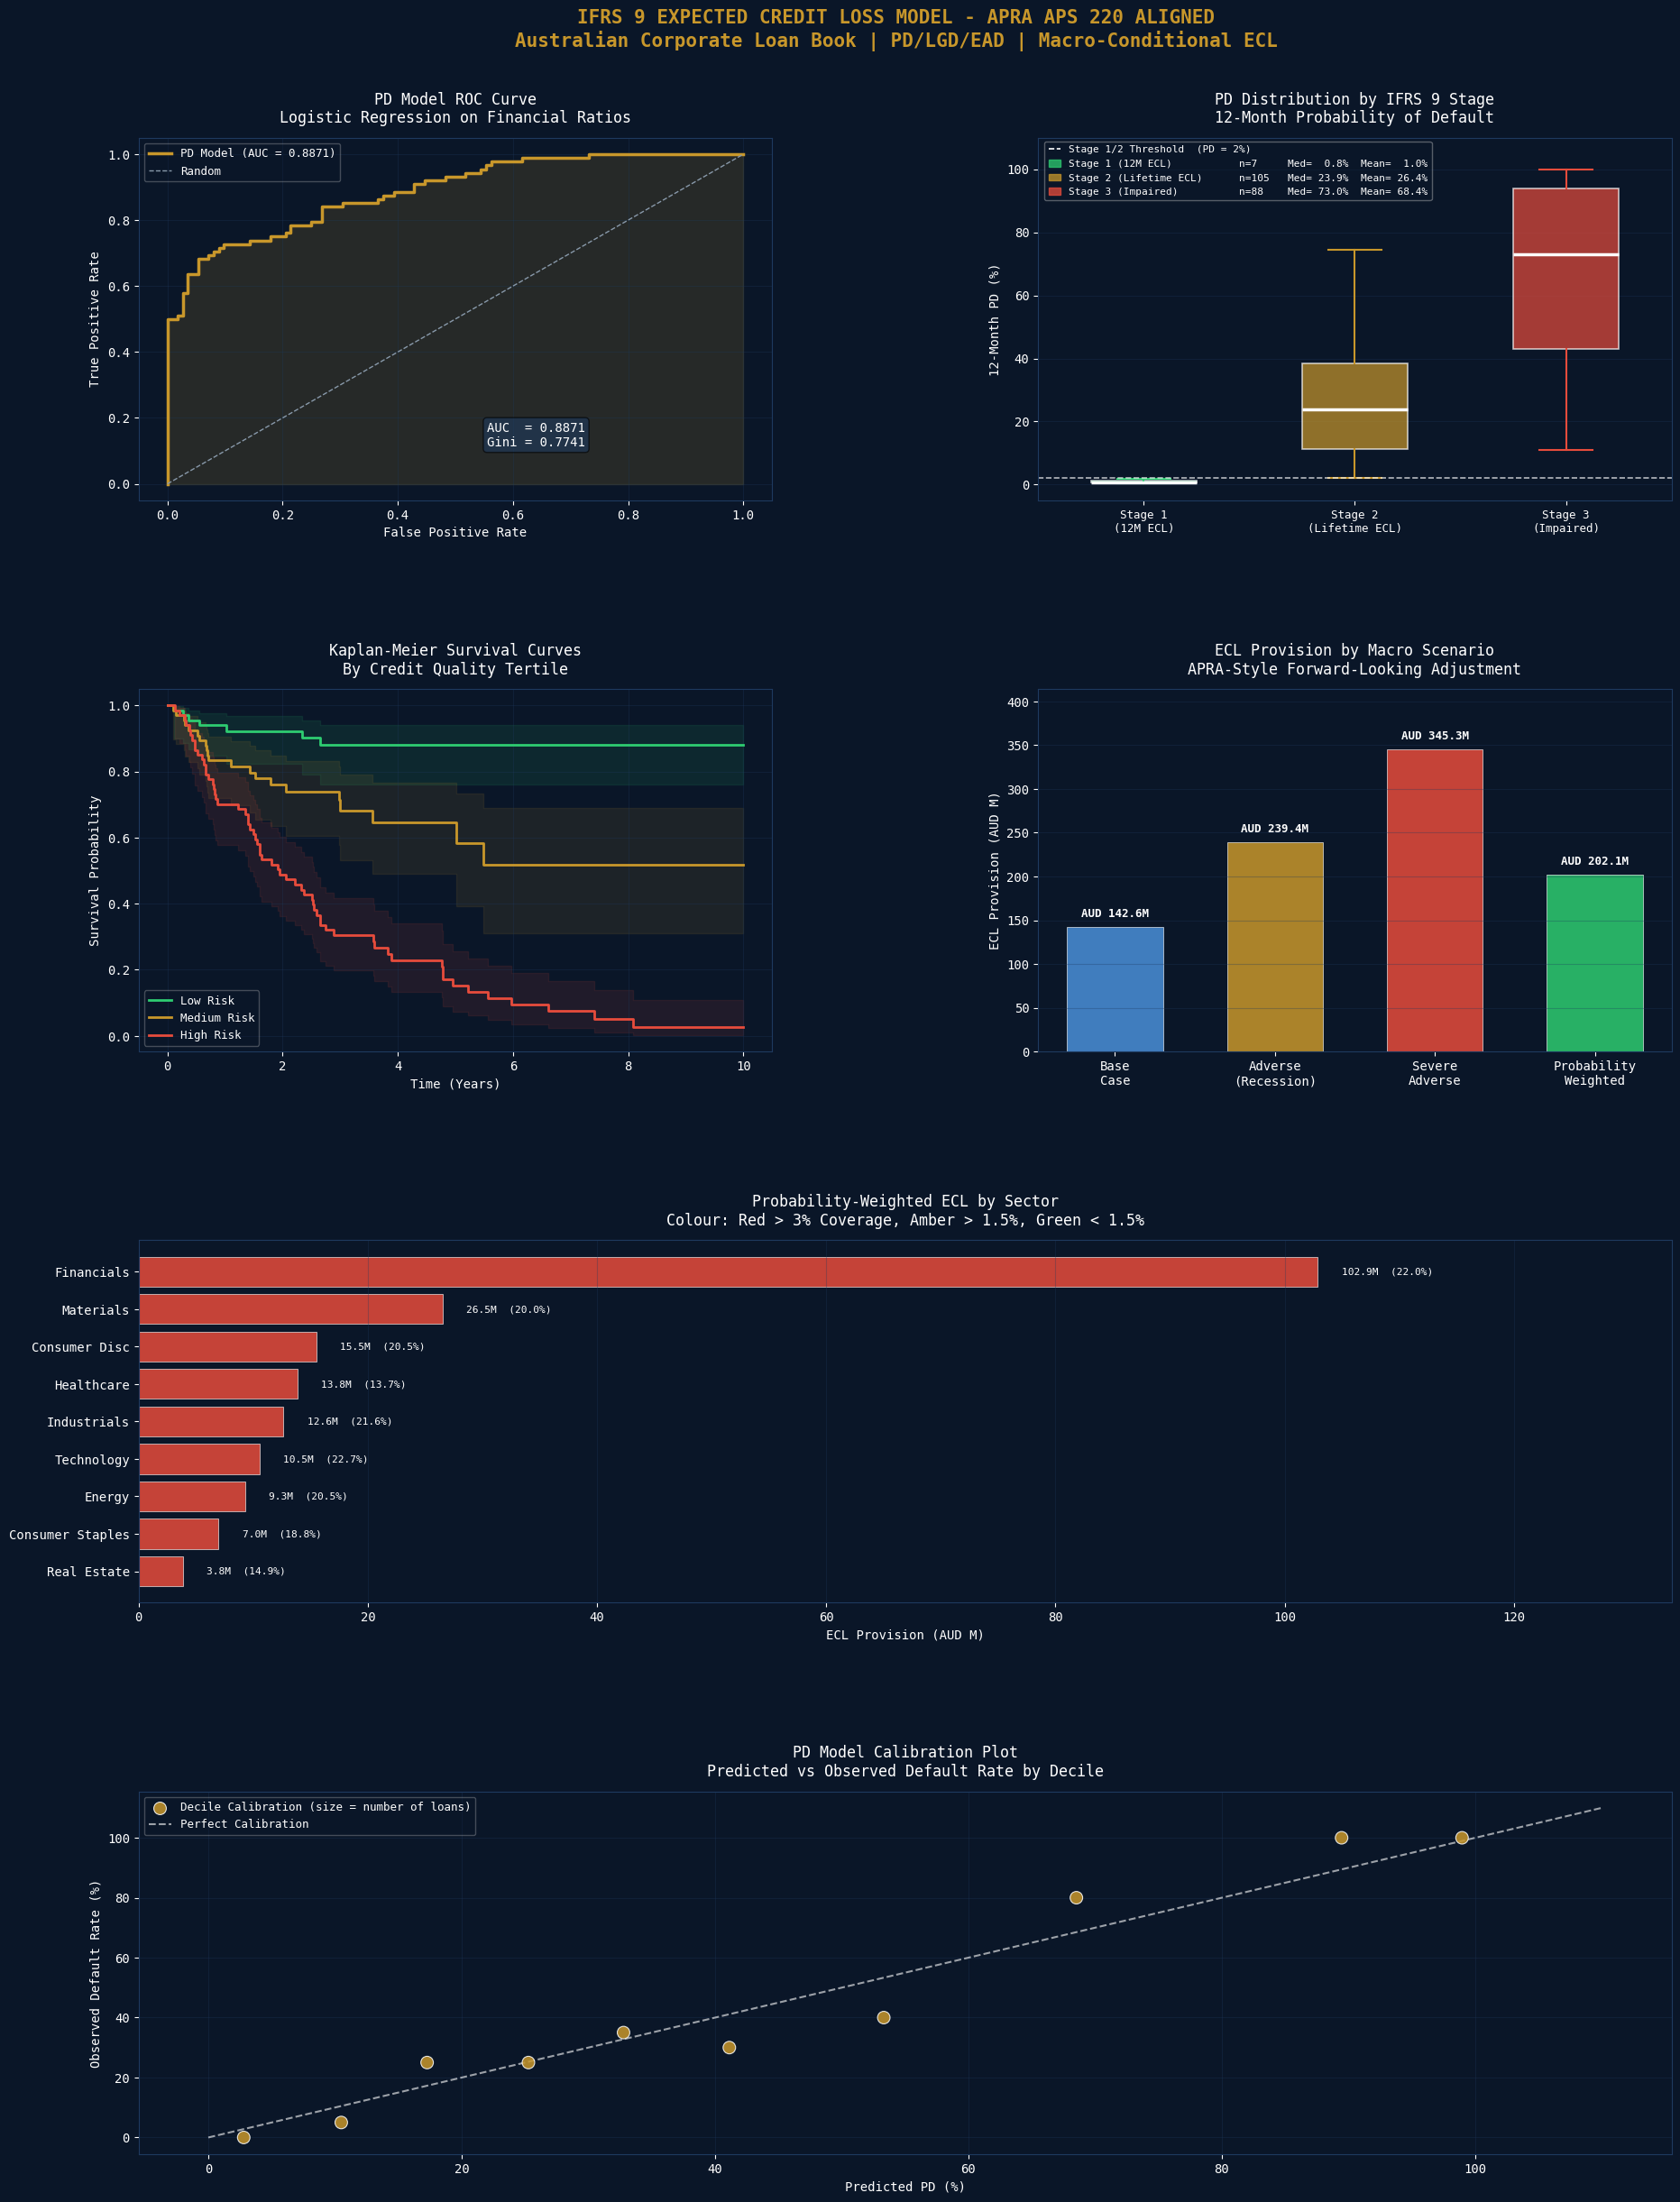

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Chart saved and downloaded!


In [20]:
from google.colab import files
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import roc_curve
from lifelines import KaplanMeierFitter
import matplotlib.patches as mpatches

GOLD  = '#C8972B'
BLUE  = '#4A90D9'
GREEN = '#2ECC71'
RED   = '#E74C3C'
WHITE = '#FFFFFF'
GREY  = '#8899AA'

fig = plt.figure(figsize=(20, 26))
fig.patch.set_facecolor('#0A1628')
gs  = gridspec.GridSpec(
    4, 2, figure=fig,
    hspace=0.52, wspace=0.42,
    left=0.08, right=0.93,
    top=0.91, bottom=0.05
)

# ── Chart 1: ROC Curve ────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(y, pd_model_probs)
ax1.plot(fpr, tpr, color=GOLD, lw=2.5, label=f'PD Model (AUC = {auc:.4f})')
ax1.plot([0, 1], [0, 1], color=GREY, lw=1.0, linestyle='--', label='Random')
ax1.fill_between(fpr, tpr, alpha=0.15, color=GOLD)
ax1.set_title('PD Model ROC Curve\nLogistic Regression on Financial Ratios',
              fontsize=12, color=WHITE, pad=12)
ax1.set_xlabel('False Positive Rate', color=WHITE)
ax1.set_ylabel('True Positive Rate', color=WHITE)
ax1.legend(fontsize=9, framealpha=0.3)
ax1.set_facecolor('#0A1628')
ax1.grid(True, alpha=0.3)
ax1.text(0.55, 0.15,
         f'AUC  = {auc:.4f}\nGini = {gini:.4f}',
         transform=ax1.transAxes, color=WHITE, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='#1E3A5F', alpha=0.6))

# ── Chart 2: PD Box Plot ──────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

stage_data   = []
stage_colors = [GREEN, GOLD, RED]

for stage in [1, 2, 3]:
    subset = loan_book[loan_book['stage'] == stage]['PD_12m'] * 100
    stage_data.append(subset.values)

bp = ax2.boxplot(
    stage_data,
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color=WHITE, linewidth=2.5),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=4, alpha=0.5)
)

for patch, c in zip(bp['boxes'], stage_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
    patch.set_edgecolor(WHITE)
    patch.set_linewidth(1.2)

for whisker, c in zip(bp['whiskers'], [GREEN, GREEN, GOLD, GOLD, RED, RED]):
    whisker.set_color(c)
for cap, c in zip(bp['caps'], [GREEN, GREEN, GOLD, GOLD, RED, RED]):
    cap.set_color(c)
for flier, c in zip(bp['fliers'], stage_colors):
    flier.set_markerfacecolor(c)
    flier.set_markeredgecolor(c)

ax2.axhline(y=2, color=WHITE, lw=1.2, linestyle='--', alpha=0.7)

# Legend with fixed-width spacing so columns line up
stage_info_leg = [
    (GREEN, 'Stage 1 (12M ECL)',      7,   stage_data[0]),
    (GOLD,  'Stage 2 (Lifetime ECL)', 105, stage_data[1]),
    (RED,   'Stage 3 (Impaired)',      88, stage_data[2]),
]

legend_handles = [
    plt.Line2D([0], [0], color=WHITE, lw=1.2, linestyle='--',
               label='Stage 1/2 Threshold  (PD = 2%)')
]
for c, name, n, data in stage_info_leg:
    median = np.median(data)
    mean   = np.mean(data)
    # Fixed width formatting so columns align
    legend_handles.append(
        mpatches.Patch(
            color=c, alpha=0.75,
            label=f'{name:<26}  n={n:<4}  Med={median:>5.1f}%  Mean={mean:>5.1f}%'
        )
    )

leg = ax2.legend(
    handles=legend_handles,
    fontsize=8, framealpha=0.4,
    loc='upper left',
    bbox_to_anchor=(0.01, 0.99),
    borderaxespad=0,
    labelspacing=0.5,
    handlelength=1.2,
    prop={'family': 'monospace', 'size': 8}
)
for text in leg.get_texts():
    text.set_color(WHITE)

ax2.set_xticks([1, 2, 3])
ax2.set_xticklabels(
    ['Stage 1\n(12M ECL)', 'Stage 2\n(Lifetime ECL)', 'Stage 3\n(Impaired)'],
    fontsize=9
)
ax2.set_title('PD Distribution by IFRS 9 Stage\n12-Month Probability of Default',
              fontsize=12, color=WHITE, pad=12)
ax2.set_ylabel('12-Month PD (%)', color=WHITE)
ax2.set_facecolor('#0A1628')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(-5, 110)

# ── Chart 3: Survival Curves ──────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
kmf = KaplanMeierFitter()
pd_tertile = pd.qcut(loan_book['PD_12m'], q=3,
                      labels=['Low Risk', 'Medium Risk', 'High Risk'])
colors_km  = [GREEN, GOLD, RED]
for label, c in zip(['Low Risk', 'Medium Risk', 'High Risk'], colors_km):
    mask = pd_tertile == label
    kmf.fit(loan_book.loc[mask, 'time_to_default'],
            event_observed=loan_book.loc[mask, 'defaulted'],
            label=label)
    kmf.plot_survival_function(ax=ax3, color=c, lw=2.0,
                                ci_show=True, ci_alpha=0.1)
ax3.set_title('Kaplan-Meier Survival Curves\nBy Credit Quality Tertile',
              fontsize=12, color=WHITE, pad=12)
ax3.set_xlabel('Time (Years)', color=WHITE)
ax3.set_ylabel('Survival Probability', color=WHITE)
ax3.legend(fontsize=9, framealpha=0.3)
ax3.set_facecolor('#0A1628')
ax3.grid(True, alpha=0.3)

# ── Chart 4: ECL Scenario Waterfall ──────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
scenario_names  = ['Base\nCase', 'Adverse\n(Recession)', 'Severe\nAdverse', 'Probability\nWeighted']
scenario_values = [total_ecl_base/1e6, total_ecl_adverse/1e6,
                   total_ecl_severe/1e6, total_ecl_wtd/1e6]
bar_colors_ecl  = [BLUE, GOLD, RED, GREEN]
bars = ax4.bar(scenario_names, scenario_values,
               color=bar_colors_ecl, alpha=0.85,
               edgecolor='white', lw=0.5, width=0.6)
ax4.set_title('ECL Provision by Macro Scenario\nAPRA-Style Forward-Looking Adjustment',
              fontsize=12, color=WHITE, pad=12)
ax4.set_ylabel('ECL Provision (AUD M)', color=WHITE)
ax4.set_facecolor('#0A1628')
ax4.grid(True, alpha=0.3, axis='y')
y_max = max(scenario_values) * 1.20
ax4.set_ylim(0, y_max)
for bar, val in zip(bars, scenario_values):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + y_max * 0.02,
             f'AUD {val:.1f}M',
             ha='center', va='bottom',
             color=WHITE, fontsize=9, fontweight='bold')

# ── Chart 5: ECL by Sector ────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, :])
sector_ecl = loan_book.groupby('sector').agg(
    ecl_wtd  = ('ECL_weighted', 'sum'),
    exposure = ('exposure_AUD', 'sum'),
    avg_pd   = ('PD_12m', 'mean')
).sort_values('ecl_wtd', ascending=True)
sector_ecl['coverage_ratio'] = sector_ecl['ecl_wtd'] / sector_ecl['exposure'] * 100

bar_colors_sector = [RED if r > 3 else GOLD if r > 1.5 else GREEN
                     for r in sector_ecl['coverage_ratio']]
bars5 = ax5.barh(sector_ecl.index, sector_ecl['ecl_wtd']/1e6,
                 color=bar_colors_sector, alpha=0.85,
                 edgecolor='white', lw=0.5)
ax5.set_title('Probability-Weighted ECL by Sector\nColour: Red > 3% Coverage, Amber > 1.5%, Green < 1.5%',
              fontsize=12, color=WHITE, pad=12)
ax5.set_xlabel('ECL Provision (AUD M)', color=WHITE)
ax5.set_facecolor('#0A1628')
ax5.grid(True, alpha=0.3, axis='x')
x_max5 = sector_ecl['ecl_wtd'].max() / 1e6
ax5.set_xlim(0, x_max5 * 1.30)
for bar, (_, row) in zip(bars5, sector_ecl.iterrows()):
    val = row['ecl_wtd'] / 1e6
    ax5.text(val + x_max5 * 0.02,
             bar.get_y() + bar.get_height()/2,
             f'{val:.1f}M  ({row["coverage_ratio"]:.1f}%)',
             va='center', color=WHITE, fontsize=8)

# ── Chart 6: Calibration Plot ─────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[3, :])
n_bins      = 10
bin_edges   = np.percentile(pd_model_probs, np.linspace(0, 100, n_bins+1))
bin_indices = np.digitize(pd_model_probs, bin_edges[1:-1])
mean_pred   = [pd_model_probs[bin_indices == i].mean() for i in range(n_bins)]
mean_actual = [y[bin_indices == i].mean() for i in range(n_bins)]
n_in_bin    = [np.sum(bin_indices == i) for i in range(n_bins)]

ax6.scatter(
    [v * 100 for v in mean_pred],
    [v * 100 for v in mean_actual],
    s=[n * 5 for n in n_in_bin],
    color=GOLD, alpha=0.85, zorder=5,
    edgecolors='white', linewidths=0.8,
    label='Decile Calibration (size = number of loans)'
)
max_val = max(max(mean_pred), max(mean_actual)) * 100 * 1.1
ax6.plot([0, max_val], [0, max_val], color=WHITE, lw=1.5,
         linestyle='--', alpha=0.6, label='Perfect Calibration')
ax6.set_title('PD Model Calibration Plot\nPredicted vs Observed Default Rate by Decile',
              fontsize=12, color=WHITE, pad=12)
ax6.set_xlabel('Predicted PD (%)', color=WHITE)
ax6.set_ylabel('Observed Default Rate (%)', color=WHITE)
ax6.legend(fontsize=9, framealpha=0.3)
ax6.set_facecolor('#0A1628')
ax6.grid(True, alpha=0.3)

fig.suptitle(
    'IFRS 9 EXPECTED CREDIT LOSS MODEL - APRA APS 220 ALIGNED\n'
    'Australian Corporate Loan Book | PD/LGD/EAD | Macro-Conditional ECL',
    fontsize=15, color=GOLD, y=0.965, fontweight='bold'
)

plt.savefig('asx_ifrs9_ecl.png', dpi=150,
            bbox_inches='tight', facecolor='#0A1628')
plt.show()
files.download('asx_ifrs9_ecl.png')
print("Chart saved and downloaded!")

In [21]:
print("\n" + "=" * 65)
print("  IFRS 9 ECL MODEL - SUMMARY REPORT")
print("=" * 65)

print(f"\n  LOAN BOOK OVERVIEW")
print(f"  Total exposures  : {N_LOANS}")
print(f"  Total exposure   : AUD {total_exposure/1e6:.1f}M")
print(f"  Observed default : {loan_book['defaulted'].mean()*100:.1f}%")
print(f"  Stage 1 count    : {(loan_book['stage']==1).sum()} ({(loan_book['stage']==1).mean()*100:.1f}%)")
print(f"  Stage 2 count    : {(loan_book['stage']==2).sum()} ({(loan_book['stage']==2).mean()*100:.1f}%)")
print(f"  Stage 3 count    : {(loan_book['stage']==3).sum()} ({(loan_book['stage']==3).mean()*100:.1f}%)")

print(f"\n  PD MODEL PERFORMANCE")
print(f"  AUC-ROC          : {auc:.4f}")
print(f"  Gini Coefficient : {gini:.4f}")
print(f"  Brier Score      : {brier:.4f}")
print(f"  CV AUC (5-fold)  : {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}")
print(f"  Mean 12M PD      : {loan_book['PD_12m'].mean()*100:.2f}%")

print(f"\n  LIFETIME PD TERM STRUCTURE (Avg Borrower)")
for t, pd_t in pd_term.items():
    print(f"  {t}Y cumulative PD : {pd_t*100:.2f}%")

print(f"\n  IFRS 9 ECL PROVISION SUMMARY")
print(f"  Base Case        : AUD {total_ecl_base/1e6:.2f}M  ({total_ecl_base/total_exposure*100:.2f}%)")
print(f"  Adverse          : AUD {total_ecl_adverse/1e6:.2f}M  ({total_ecl_adverse/total_exposure*100:.2f}%)")
print(f"  Severe Adverse   : AUD {total_ecl_severe/1e6:.2f}M  ({total_ecl_severe/total_exposure*100:.2f}%)")
print(f"  Probability Wtd  : AUD {total_ecl_wtd/1e6:.2f}M  ({total_ecl_wtd/total_exposure*100:.2f}%)")

print(f"\n  MACRO SCENARIO WEIGHTS (APRA-style)")
for s, params in scenarios.items():
    print(f"  {s:<20}: {params['weight']*100:.0f}% weight  |  PD mult {params['pd_mult']:.2f}x  |  LGD mult {params['lgd_mult']:.2f}x")

print("\n" + "=" * 65)
print("  PROJECT 13 COMPLETE!")
print("  File saved: asx_ifrs9_ecl.png")
print("=" * 65)


  IFRS 9 ECL MODEL - SUMMARY REPORT

  LOAN BOOK OVERVIEW
  Total exposures  : 200
  Total exposure   : AUD 990.2M
  Observed default : 44.0%
  Stage 1 count    : 7 (3.5%)
  Stage 2 count    : 105 (52.5%)
  Stage 3 count    : 88 (44.0%)

  PD MODEL PERFORMANCE
  AUC-ROC          : 0.8871
  Gini Coefficient : 0.7741
  Brier Score      : 0.1305
  CV AUC (5-fold)  : 0.8662 +/- 0.0628
  Mean 12M PD      : 44.00%

  LIFETIME PD TERM STRUCTURE (Avg Borrower)
  1Y cumulative PD : 14.36%
  2Y cumulative PD : 25.14%
  3Y cumulative PD : 36.49%
  5Y cumulative PD : 47.64%
  7Y cumulative PD : 58.75%
  10Y cumulative PD : 66.32%

  IFRS 9 ECL PROVISION SUMMARY
  Base Case        : AUD 142.64M  (14.40%)
  Adverse          : AUD 239.43M  (24.18%)
  Severe Adverse   : AUD 345.25M  (34.87%)
  Probability Wtd  : AUD 202.07M  (20.41%)

  MACRO SCENARIO WEIGHTS (APRA-style)
  Base                : 55% weight  |  PD mult 1.00x  |  LGD mult 1.00x
  Adverse             : 30% weight  |  PD mult 1.50x  |  L